# 04 - Modèle Random Forest

## Introduction

Dans ce quatrième notebook du projet **Employee Attrition Prediction - RH**, nous entraînons un modèle **Random Forest**.

Random Forest est une méthode d'ensemble basée sur plusieurs arbres de décision. Au lieu d'utiliser un seul arbre comme dans le notebook précédent, ce modèle combine plusieurs arbres afin d'obtenir une prédiction plus stable et souvent plus robuste.

L'objectif est de comparer ce modèle avec le **Decision Tree** et de voir s'il permet de mieux détecter les employés qui risquent de quitter l'entreprise.

## 1. Importation des bibliothèques

In [60]:
import os

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

In [61]:
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (10, 6)

**Interprétation :** Ces bibliothèques permettent de charger les données, de préparer les variables catégorielles, d'entraîner un modèle Random Forest, d'évaluer ses performances et de sauvegarder les résultats.

## 2. Chargement du dataset

In [62]:
df = pd.read_csv("../data/raw/WA_Fn-UseC_-HR-Employee-Attrition.csv")
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [63]:
df.shape

(1470, 35)

**Interprétation :** Le dataset est rechargé depuis le fichier CSV original. Cela permet de repartir de la même base que les notebooks précédents et d'appliquer les mêmes étapes de préparation.

## 3. Nettoyage des colonnes non utiles

In [64]:
columns_to_drop = ["EmployeeCount", "EmployeeNumber", "Over18", "StandardHours"]

# On supprime seulement les colonnes qui existent dans le dataset.
existing_columns_to_drop = [col for col in columns_to_drop if col in df.columns]
df = df.drop(columns=existing_columns_to_drop)

existing_columns_to_drop

['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']

**Interprétation :** Ces colonnes sont supprimées car elles sont constantes, identifiantes ou peu utiles pour l'apprentissage. Par exemple, `EmployeeNumber` est un identifiant et ne doit pas influencer la prédiction.

## 4. Séparation des variables explicatives et de la variable cible

In [65]:
X = df.drop("Attrition", axis=1)
y = df["Attrition"].map({"Yes": 1, "No": 0})

print("Dimensions de X :", X.shape)
print("Dimensions de y :", y.shape)
print("Distribution de la cible :")
print(y.value_counts())

Dimensions de X : (1470, 30)
Dimensions de y : (1470,)
Distribution de la cible :
Attrition
0    1233
1     237
Name: count, dtype: int64


**Interprétation :** `Attrition` est la variable cible à prédire. Elle est transformée en variable numérique : `Yes = 1` signifie que l'employé quitte l'entreprise, et `No = 0` signifie qu'il reste.

## 5. Identification des variables numériques et catégorielles

In [66]:
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print(f"Nombre de variables numériques : {len(numeric_features)}")
print(numeric_features)

print(f"\nNombre de variables catégorielles : {len(categorical_features)}")
print(categorical_features)

Nombre de variables numériques : 23
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Nombre de variables catégorielles : 7
['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


**Interprétation :** Les variables numériques peuvent être utilisées directement par Random Forest. Les variables catégorielles doivent être transformées en valeurs numériques avant l'entraînement du modèle.

## 6. Création du préprocesseur pour Random Forest

In [67]:
preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", "passthrough", numeric_features),
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

preprocessor

ColumnTransformer(transformers=[('numeric', 'passthrough',
                                 ['Age', 'DailyRate', 'DistanceFromHome',
                                  'Education', 'EnvironmentSatisfaction',
                                  'HourlyRate', 'JobInvolvement', 'JobLevel',
                                  'JobSatisfaction', 'MonthlyIncome',
                                  'MonthlyRate', 'NumCompaniesWorked',
                                  'PercentSalaryHike', 'PerformanceRating',
                                  'RelationshipSatisfaction',
                                  'StockOptionLevel', 'TotalWorkingYears',
                                  'TrainingTimesLastYear', 'WorkLifeBalance',
                                  'YearsAtCompany', 'YearsInCurrentRole',
                                  'YearsSinceLastPromotion',
                                  'YearsWithCurrManager']),
                                ('categorical',
                                 OneHotEncoder(handle_unknown='ignore'),
                                 ['BusinessTravel', 'Department',
                                  'EducationField', 'Gender', 'JobRole',
                                  'MaritalStatus', 'OverTime'])])

**Interprétation :** Random Forest n'a pas besoin de `StandardScaler`, car il n'est pas sensible à l'échelle des variables. En revanche, toutes les variables doivent être numériques, donc les variables catégorielles sont encodées avec `OneHotEncoder`.

## 7. Séparation train/test

In [68]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print("X_train :", X_train.shape)
print("X_test :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test :", y_test.shape)

X_train : (1176, 30)
X_test : (294, 30)
y_train : (1176,)
y_test : (294,)


In [69]:
print("Distribution de y_train :")
print(y_train.value_counts(normalize=True) * 100)

print("\nDistribution de y_test :")
print(y_test.value_counts(normalize=True) * 100)

Distribution de y_train :
Attrition
0    83.843537
1    16.156463
Name: proportion, dtype: float64

Distribution de y_test :
Attrition
0    84.013605
1    15.986395
Name: proportion, dtype: float64


## 8. Modèle Random Forest baseline

In [70]:
rf_model_baseline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=100,
            random_state=42,
        )),
    ]
)

rf_model_baseline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric', 'passthrough',
                                                  ['Age', 'DailyRate',
                                                   'DistanceFromHome',
                                                   'Education',
                                                   'EnvironmentSatisfaction',
                                                   'HourlyRate',
                                                   'JobInvolvement', 'JobLevel',
                                                   'JobSatisfaction',
                                                   'MonthlyIncome',
                                                   'MonthlyRate',
                                                   'NumCompaniesWorked',
                                                   'PercentSalaryHike',
                                                   'PerformanceRating',
                                                   'RelationshipSatisfaction',
                                                   'StockOp...
                                                   'TotalWorkingYears',
                                                   'TrainingTimesLastYear',
                                                   'WorkLifeBalance',
                                                   'YearsAtCompany',
                                                   'YearsInCurrentRole',
                                                   'YearsSinceLastPromotion',
                                                   'YearsWithCurrManager']),
                                                 ('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['BusinessTravel',
                                                   'Department',
                                                   'EducationField', 'Gender',
                                                   'JobRole', 'MaritalStatus',
                                                   'OverTime'])])),
                ('classifier', RandomForestClassifier(random_state=42))])

**Interprétation :** Ce pipeline contient le préprocesseur et le modèle Random Forest baseline. Le modèle utilise 100 arbres de décision et servira de point de départ pour la comparaison.

## 9. Entraînement du modèle baseline

In [71]:
rf_model_baseline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric', 'passthrough',
                                                  ['Age', 'DailyRate',
                                                   'DistanceFromHome',
                                                   'Education',
                                                   'EnvironmentSatisfaction',
                                                   'HourlyRate',
                                                   'JobInvolvement', 'JobLevel',
                                                   'JobSatisfaction',
                                                   'MonthlyIncome',
                                                   'MonthlyRate',
                                                   'NumCompaniesWorked',
                                                   'PercentSalaryHike',
                                                   'PerformanceRating',
                                                   'RelationshipSatisfaction',
                                                   'StockOp...
                                                   'TotalWorkingYears',
                                                   'TrainingTimesLastYear',
                                                   'WorkLifeBalance',
                                                   'YearsAtCompany',
                                                   'YearsInCurrentRole',
                                                   'YearsSinceLastPromotion',
                                                   'YearsWithCurrManager']),
                                                 ('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['BusinessTravel',
                                                   'Department',
                                                   'EducationField', 'Gender',
                                                   'JobRole', 'MaritalStatus',
                                                   'OverTime'])])),
                ('classifier', RandomForestClassifier(random_state=42))])

**Interprétation :** Le modèle apprend à partir des données d'entraînement. Random Forest construit plusieurs arbres et combine leurs prédictions.

## 10. Prédictions du modèle baseline

In [72]:
y_pred_rf_baseline = rf_model_baseline.predict(X_test)
y_pred_rf_baseline[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

**Interprétation :** Les prédictions sont faites sur les données de test, qui n'ont pas été utilisées pendant l'entraînement. Cela permet d'évaluer la capacité du modèle à généraliser.

## 11. Évaluation du modèle baseline

In [73]:
accuracy_rf_baseline = accuracy_score(y_test, y_pred_rf_baseline)
precision_rf_baseline = precision_score(y_test, y_pred_rf_baseline, zero_division=0)
recall_rf_baseline = recall_score(y_test, y_pred_rf_baseline, zero_division=0)
f1_rf_baseline = f1_score(y_test, y_pred_rf_baseline, zero_division=0)

metrics_rf_baseline_df = pd.DataFrame(
    {
        "model": ["Random Forest Baseline"],
        "accuracy": [accuracy_rf_baseline],
        "precision": [precision_rf_baseline],
        "recall": [recall_rf_baseline],
        "f1_score": [f1_rf_baseline],
    }
)

metrics_rf_baseline_df

,model,accuracy,precision,recall,f1_score
0,Random Forest Baseline,0.85034,0.636364,0.148936,0.241379


**Interprétation des métriques :**

On remarque que le modèle Random Forest Baseline obtient une accuracy de 0,8503, soit environ 85,03 %.

Cela signifie que le modèle prédit correctement une grande partie des employés.
À première vue, ce score semble meilleur que celui du Decision Tree.

Cependant, dans ce projet, il ne faut pas se baser uniquement sur l’accuracy, car les classes sont déséquilibrées.
Il y a généralement beaucoup plus d’employés qui restent dans l’entreprise que d’employés qui la quittent.

La précision est de 0,6364, soit environ 63,64 %.
Cela signifie que lorsque le modèle prédit qu’un employé risque de quitter l’entreprise, il a assez souvent raison.

Par contre, le recall est de 0,1489, soit environ 14,89 %.
Cela signifie que le modèle détecte seulement une petite partie des employés qui ont réellement quitté l’entreprise.
Il rate donc beaucoup d’employés à risque.

Le F1-score est de 0,2414, soit environ 24,14 %.
Ce score est faible, car le recall est très bas.
Cela montre que le modèle n’est pas encore efficace pour détecter la classe importante Attrition = Yes.

Cette observation est importante car l’objectif principal du projet est de prédire les employés qui risquent de quitter l’entreprise.
Même si le Random Forest Baseline a une bonne accuracy, il détecte mal les employés en attrition.

In [74]:
print(classification_report(y_test, y_pred_rf_baseline, target_names=["No", "Yes"]))

              precision    recall  f1-score   support

          No       0.86      0.98      0.92       247
         Yes       0.64      0.15      0.24        47

    accuracy                           0.85       294
   macro avg       0.75      0.57      0.58       294
weighted avg       0.82      0.85      0.81       294



**Interprétation :** 
On remarque que le modèle Random Forest Baseline obtient une accuracy globale de 0,85, soit environ 85 %.

Le dataset est déséquilibré : la classe No contient 247 employés, alors que la classe Yes contient seulement 47 employés.

Pour la classe No, la précision est de 0,86.
Cela signifie que lorsque le modèle prédit qu’un employé ne quitte pas l’entreprise, il a souvent raison.

Le recall de la classe No est de 0,98.
Cela signifie que le modèle détecte presque tous les employés qui restent dans l’entreprise.

Le F1-score de la classe No est de 0,92.
Cela montre que le modèle est très performant pour reconnaître les employés qui ne quittent pas l’entreprise.

Par contre, pour la classe Yes, les résultats sont faibles.
La précision est de 0,64, ce qui veut dire que quand le modèle prédit Attrition = Yes, il a assez souvent raison.

Mais le recall est seulement de 0,15.
Cela signifie que le modèle détecte seulement une petite partie des employés qui ont réellement quitté l’entreprise.
Il rate donc beaucoup d’employés à risque.

Le F1-score de la classe Yes est de 0,24.
Ce score est faible, car le modèle n’arrive pas bien à trouver les employés qui risquent de quitter l’entreprise.

Même si le modèle a une bonne accuracy, il est surtout fort pour prédire la classe majoritaire No.


## 12. Matrice de confusion baseline

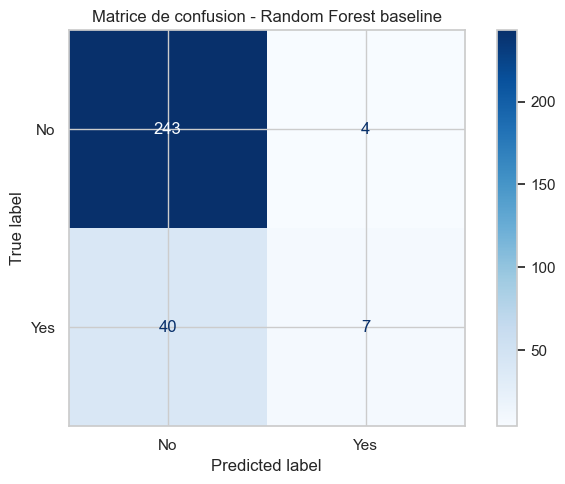

In [75]:
cm_rf_baseline = confusion_matrix(y_test, y_pred_rf_baseline)

disp_rf_baseline = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf_baseline,
    display_labels=["No", "Yes"],
)

fig, ax = plt.subplots(figsize=(7, 5))
disp_rf_baseline.plot(cmap="Blues", ax=ax, values_format="d")
plt.title("Matrice de confusion - Random Forest baseline")
plt.tight_layout()
plt.savefig("../results/figures/confusion_matrix_random_forest_baseline.png", dpi=300, bbox_inches="tight")
plt.show()

**Interprétation :** 

On remarque que la matrice de confusion du Random Forest Baseline montre que le modèle prédit très bien la classe Attrition = No.

Le modèle a correctement prédit 243 employés comme Attrition = No.
Cela signifie que ces employés ne quittent pas l’entreprise, et le modèle les a bien classés.

Le modèle a aussi correctement prédit seulement 7 employés comme Attrition = Yes.
Cela signifie que le modèle détecte très peu d’employés qui ont réellement quitté l’entreprise.

On remarque aussi que le modèle a prédit 4 employés comme Attrition = Yes, alors qu’ils sont réellement No.
Ce sont des fausses alertes.
Ce nombre est faible, donc le modèle ne fait pas beaucoup de fausses alertes.

Par contre, le modèle a prédit 40 employés comme Attrition = No, alors qu’ils sont réellement Yes.
Cela signifie que le modèle a raté 40 employés qui ont réellement quitté l’entreprise.

Même si le modèle reconnaît très bien les employés qui restent, il n’est pas efficace pour trouver les employés à risque.

Cette matrice confirme aussi que l’accuracy peut être trompeuse.
Le modèle a une bonne accuracy parce qu’il prédit très bien la classe majoritaire No, mais il détecte mal la classe minoritaire Yes.

## 13. Amélioration du modèle Random Forest

Le modèle baseline peut parfois bien prédire la classe majoritaire **Attrition = No**, mais avoir plus de difficulté avec la classe minoritaire **Attrition = Yes**.

Pour cela, nous testons un modèle amélioré avec `class_weight="balanced"` et quelques paramètres pour contrôler la complexité du modèle.

In [76]:
rf_model_improved = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            class_weight="balanced",
            max_depth=8,
            min_samples_leaf=5,
        )),
    ]
)

rf_model_improved

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric', 'passthrough',
                                                  ['Age', 'DailyRate',
                                                   'DistanceFromHome',
                                                   'Education',
                                                   'EnvironmentSatisfaction',
                                                   'HourlyRate',
                                                   'JobInvolvement', 'JobLevel',
                                                   'JobSatisfaction',
                                                   'MonthlyIncome',
                                                   'MonthlyRate',
                                                   'NumCompaniesWorked',
                                                   'PercentSalaryHike',
                                                   'PerformanceRating',
                                                   'RelationshipSatisfaction',
                                                   'StockOp...
                                                   'YearsInCurrentRole',
                                                   'YearsSinceLastPromotion',
                                                   'YearsWithCurrManager']),
                                                 ('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['BusinessTravel',
                                                   'Department',
                                                   'EducationField', 'Gender',
                                                   'JobRole', 'MaritalStatus',
                                                   'OverTime'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced', max_depth=8,
                                        min_samples_leaf=5, n_estimators=300,
                                        random_state=42))])

**Interprétation :** Le modèle amélioré utilise plus d'arbres, tient compte du déséquilibre des classes avec `class_weight="balanced"`, et limite la complexité avec `max_depth` et `min_samples_leaf`.

## 14. Entraînement et prédictions du modèle amélioré

In [77]:
rf_model_improved.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric', 'passthrough',
                                                  ['Age', 'DailyRate',
                                                   'DistanceFromHome',
                                                   'Education',
                                                   'EnvironmentSatisfaction',
                                                   'HourlyRate',
                                                   'JobInvolvement', 'JobLevel',
                                                   'JobSatisfaction',
                                                   'MonthlyIncome',
                                                   'MonthlyRate',
                                                   'NumCompaniesWorked',
                                                   'PercentSalaryHike',
                                                   'PerformanceRating',
                                                   'RelationshipSatisfaction',
                                                   'StockOp...
                                                   'YearsInCurrentRole',
                                                   'YearsSinceLastPromotion',
                                                   'YearsWithCurrManager']),
                                                 ('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['BusinessTravel',
                                                   'Department',
                                                   'EducationField', 'Gender',
                                                   'JobRole', 'MaritalStatus',
                                                   'OverTime'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced', max_depth=8,
                                        min_samples_leaf=5, n_estimators=300,
                                        random_state=42))])

In [78]:
y_pred_rf_improved = rf_model_improved.predict(X_test)
y_pred_rf_improved[:10]

array([1, 0, 0, 0, 0, 0, 0, 0, 0, 1])

**Interprétation :** Le modèle amélioré est entraîné sur les mêmes données que le baseline, puis évalué sur le même ensemble de test. Cela rend la comparaison plus juste.

## 15. Évaluation du modèle amélioré

In [79]:
accuracy_rf_improved = accuracy_score(y_test, y_pred_rf_improved)
precision_rf_improved = precision_score(y_test, y_pred_rf_improved, zero_division=0)
recall_rf_improved = recall_score(y_test, y_pred_rf_improved, zero_division=0)
f1_rf_improved = f1_score(y_test, y_pred_rf_improved, zero_division=0)

metrics_rf_improved_df = pd.DataFrame(
    {
        "model": ["Random Forest Improved"],
        "accuracy": [accuracy_rf_improved],
        "precision": [precision_rf_improved],
        "recall": [recall_rf_improved],
        "f1_score": [f1_rf_improved],
    }
)

metrics_rf_improved_df

,model,accuracy,precision,recall,f1_score
0,Random Forest Improved,0.840136,0.5,0.404255,0.447059


**Interprétation :** 

On remarque que le modèle Random Forest Improved obtient une accuracy de 0,8401, soit environ 84,01 %.

Cette accuracy est légèrement plus faible que celle du Random Forest baseline.
Cela signifie que le modèle amélioré fait un peu moins de bonnes prédictions globales.

La précision est de 0,50, soit 50 %.
Cela signifie que, parmi les employés prédits comme Attrition = Yes, environ la moitié ont réellement quitté l’entreprise.

Le recall est de 0,4043, soit environ 40,43 %.
Cela signifie que le modèle arrive à détecter environ 40 % des employés qui ont réellement quitté l’entreprise.

Le F1-score est de 0,4471, soit environ 44,71 %.
Ce score montre un meilleur équilibre entre la précision et le recall par rapport au Random Forest baseline.

Même si l’accuracy diminue légèrement, le modèle amélioré détecte beaucoup mieux la classe importante Attrition = Yes.

In [80]:
print(classification_report(y_test, y_pred_rf_improved, target_names=["No", "Yes"]))

              precision    recall  f1-score   support

          No       0.89      0.92      0.91       247
         Yes       0.50      0.40      0.45        47

    accuracy                           0.84       294
   macro avg       0.70      0.66      0.68       294
weighted avg       0.83      0.84      0.83       294



**Interprétation :** On remarque que le modèle Random Forest Improved donne une accuracy de 0,84.
Cela veut dire que le modèle prédit correctement environ 84 % des employés.

Mais cette accuracy ne suffit pas pour juger le modèle, parce que les classes ne sont pas équilibrées.
Il y a 247 employés dans la classe No, contre seulement 47 employés dans la classe Yes.

Pour la classe No, le modèle donne de bons résultats.
La précision est de 0,89, le recall est de 0,92 et le F1-score est de 0,91.
Cela veut dire que le modèle reconnaît bien les employés qui ne quittent pas l’entreprise.

Pour la classe Yes, les résultats sont moins forts, mais ils sont meilleurs que le modèle Random Forest baseline.
La précision est de 0,50, donc quand le modèle prédit qu’un employé va quitter l’entreprise, il a raison environ une fois sur deux.

Le recall est de 0,40.
Cela veut dire que le modèle arrive à détecter environ 40 % des employés qui ont réellement quitté l’entreprise.
Il rate encore certains employés à risque, mais il détecte mieux la classe Yes qu’avant.

Le F1-score de la classe Yes est de 0,45.
Cela montre que le modèle amélioré a un meilleur équilibre entre la précision et le recall.

Cette observation est importante parce que dans notre projet, l’objectif principal est de prédire les employés qui risquent de quitter l’entreprise.
Donc, même si l’accuracy a un peu diminué par rapport au baseline, le modèle amélioré est plus utile car il détecte mieux les cas Attrition = Yes.

## 16. Matrice de confusion du modèle amélioré

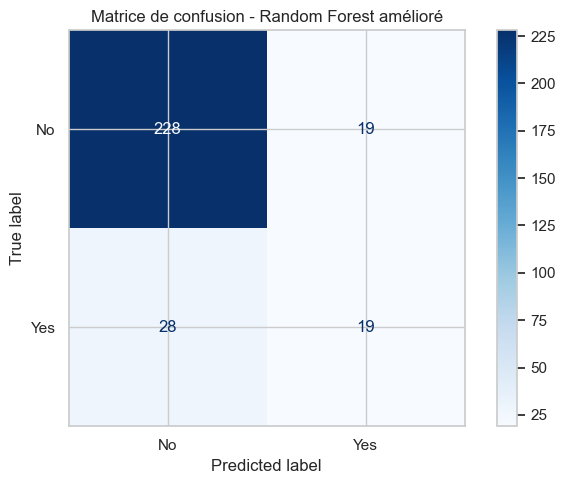

In [81]:
cm_rf_improved = confusion_matrix(y_test, y_pred_rf_improved)

disp_rf_improved = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf_improved,
    display_labels=["No", "Yes"],
)

fig, ax = plt.subplots(figsize=(7, 5))
disp_rf_improved.plot(cmap="Blues", ax=ax, values_format="d")
plt.title("Matrice de confusion - Random Forest amélioré")
plt.tight_layout()
plt.savefig("../results/figures/confusion_matrix_random_forest_improved.png", dpi=300, bbox_inches="tight")
plt.show()

**Interprétation :** On remarque que la matrice de confusion du Random Forest Improved montre que le modèle prédit encore très bien la classe Attrition = No.

Le modèle a correctement prédit 228 employés comme Attrition = No.
Cela signifie que ces employés ne quittent pas l’entreprise, et le modèle les a bien classés.

Le modèle a aussi correctement prédit 19 employés comme Attrition = Yes.
Cela signifie que le modèle a réussi à détecter 19 employés qui ont réellement quitté l’entreprise.

Par contre, le modèle a prédit 19 employés comme Attrition = Yes, alors qu’ils sont réellement No.
Ce sont des fausses alertes.
Cela veut dire que le modèle pense que certains employés vont quitter l’entreprise, alors qu’ils restent finalement.

Le modèle a aussi prédit 28 employés comme Attrition = No, alors qu’ils sont réellement Yes.
Cela signifie que le modèle a raté 28 employés qui ont réellement quitté l’entreprise.

Par rapport au Random Forest baseline, le modèle amélioré détecte mieux les employés qui quittent l’entreprise : il passe de 7 bonnes prédictions Yes à 19.

Cependant, il fait aussi plus de fausses alertes qu’avant.
Cela montre que le modèle amélioré est plus sensible à la classe Yes, mais il reste encore perfectible.

## 17. Importance des variables

In [82]:
fitted_preprocessor = rf_model_improved.named_steps["preprocessor"]
feature_names = fitted_preprocessor.get_feature_names_out()
feature_importances = rf_model_improved.named_steps["classifier"].feature_importances_

feature_importance_df = pd.DataFrame(
    {
        "feature": feature_names,
        "importance": feature_importances,
    }
).sort_values(by="importance", ascending=False)

top_15_features = feature_importance_df.head(15)
top_15_features

,feature,importance
9,numeric__MonthlyIncome,0.077950
0,numeric__Age,0.067148
16,numeric__TotalWorkingYears,0.063336
19,numeric__YearsAtCompany,0.052188
49,categorical__OverTime_No,0.045510
1,numeric__DailyRate,0.044927
22,numeric__YearsWithCurrManager,0.042215
50,categorical__OverTime_Yes,0.040743
2,numeric__DistanceFromHome,0.040542
15,numeric__StockOptionLevel,0.039477


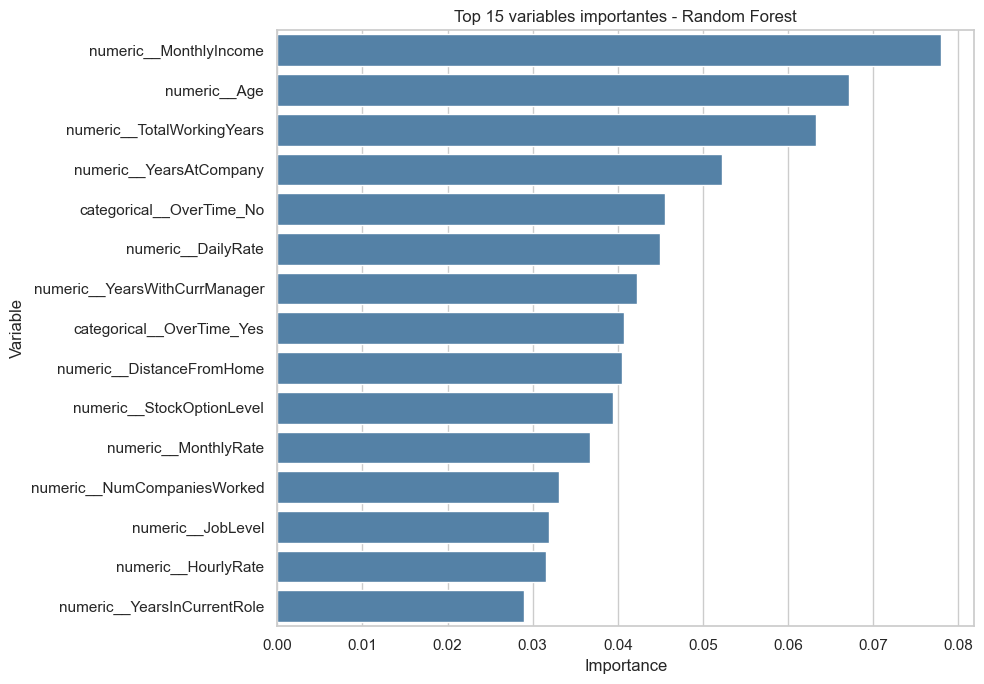

In [83]:
plt.figure(figsize=(10, 7))
sns.barplot(
    data=top_15_features,
    x="importance",
    y="feature",
    color="steelblue",
)
plt.title("Top 15 variables importantes - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Variable")
plt.tight_layout()
plt.savefig("../results/figures/random_forest_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

**Interprétation :** On remarque que ce graphique présente les 15 variables les plus importantes pour le modèle Random Forest.

La variable la plus importante est MonthlyIncome.
Cela signifie que le revenu mensuel joue un rôle important dans les décisions du modèle pour prédire l’attrition.

Ensuite, on trouve aussi Age, TotalWorkingYears et YearsAtCompany.
Cela montre que l’âge, l’expérience totale et l’ancienneté dans l’entreprise sont des variables importantes pour distinguer les employés qui restent et ceux qui quittent l’entreprise.

On remarque aussi que les variables liées aux heures supplémentaires apparaissent dans le classement, comme OverTime_No et OverTime_Yes.
Cela confirme que les heures supplémentaires peuvent influencer le risque d’attrition.

D’autres variables comme DistanceFromHome, StockOptionLevel, NumCompaniesWorked, JobLevel et YearsInCurrentRole sont aussi importantes.
Cela signifie que le modèle utilise plusieurs informations RH pour faire ses prédictions, et pas seulement une seule variable.

## 18. Sauvegarde des métriques

In [84]:
metrics_dir = "../results/metrics"
os.makedirs(metrics_dir, exist_ok=True)

metrics_rf_baseline_df.to_csv(f"{metrics_dir}/random_forest_baseline_metrics.csv", index=False)
metrics_rf_improved_df.to_csv(f"{metrics_dir}/random_forest_improved_metrics.csv", index=False)

print("Métriques sauvegardées dans ../results/metrics")

Métriques sauvegardées dans ../results/metrics


Les métriques du modèle baseline et du modèle amélioré sont sauvegardées dans deux fichiers CSV. Cela facilitera la comparaison avec les autres modèles du projet.

## 19. Sauvegarde des modèles

In [85]:
models_dir = "../results/models"
os.makedirs(models_dir, exist_ok=True)

joblib.dump(rf_model_baseline, f"{models_dir}/random_forest_baseline_model.joblib")
joblib.dump(rf_model_improved, f"{models_dir}/random_forest_improved_model.joblib")

print("Modèles sauvegardés dans ../results/models")

Modèles sauvegardés dans ../results/models


Les pipelines complets sont sauvegardés avec `joblib`. Ils contiennent à la fois le prétraitement et le modèle, ce qui permet de les réutiliser plus facilement.

## 20. Comparaison baseline vs amélioré

In [86]:
comparison_rf_df = pd.concat(
    [metrics_rf_baseline_df, metrics_rf_improved_df],
    ignore_index=True,
)

comparison_rf_df[["model", "accuracy", "precision", "recall", "f1_score"]]

,model,accuracy,precision,recall,f1_score
0,Random Forest Baseline,0.850340,0.636364,0.148936,0.241379
1,Random Forest Improved,0.840136,0.500000,0.404255,0.447059


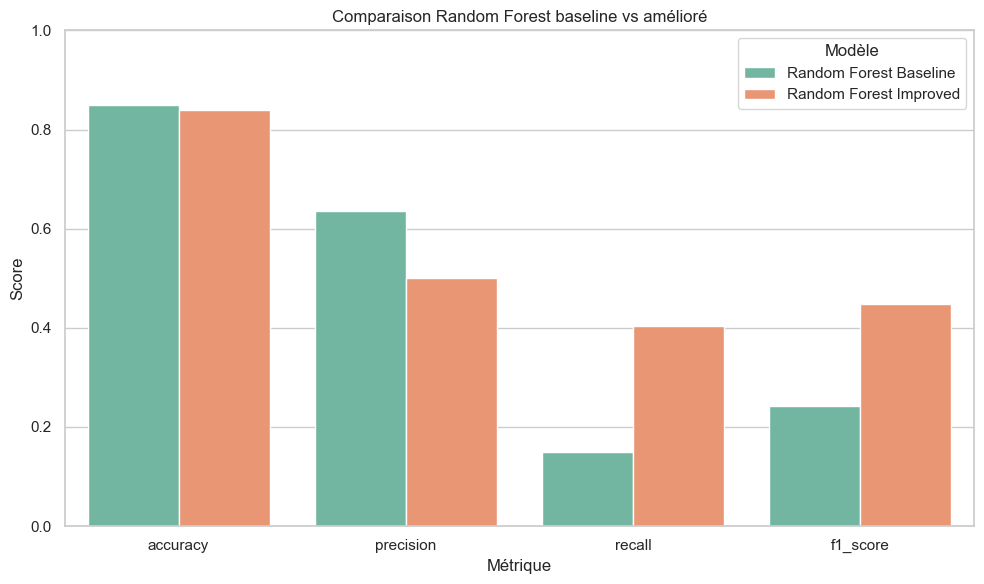

In [87]:
comparison_rf_long = comparison_rf_df.melt(
    id_vars="model",
    value_vars=["accuracy", "precision", "recall", "f1_score"],
    var_name="metric",
    value_name="score",
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=comparison_rf_long,
    x="metric",
    y="score",
    hue="model",
)
plt.title("Comparaison Random Forest baseline vs amélioré")
plt.xlabel("Métrique")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend(title="Modèle")
plt.tight_layout()
plt.savefig("../results/figures/random_forest_baseline_vs_improved.png", dpi=300, bbox_inches="tight")
plt.show()

**Interprétation :** On remarque que le Random Forest Baseline a une accuracy de 0,8503, alors que le Random Forest Improved a une accuracy de 0,8401.

Cela signifie que le modèle baseline donne une accuracy légèrement meilleure.
Mais cette différence est faible, et l’accuracy seule ne suffit pas pour choisir le meilleur modèle, surtout avec un dataset déséquilibré.

Pour la precision, le modèle baseline obtient 0,6364, alors que le modèle amélioré obtient 0,5000.
Cela signifie que le modèle baseline fait moins de fausses alertes quand il prédit Attrition = Yes.

Par contre, le recall change beaucoup.
Le Random Forest Baseline a un recall de 0,1489, alors que le Random Forest Improved atteint 0,4043.
Cela signifie que le modèle amélioré détecte beaucoup plus d’employés qui ont réellement quitté l’entreprise.

Le F1-score augmente aussi.
Il passe de 0,2414 pour le modèle baseline à 0,4471 pour le modèle amélioré.
Cela montre que le modèle amélioré a un meilleur équilibre entre la precision et le recall.

Cette comparaison est importante car, dans notre projet, l’objectif principal est de prédire les employés qui risquent de quitter l’entreprise.
Même si le modèle baseline a une meilleure accuracy et une meilleure precision, il détecte très peu les employés en attrition.
Le modèle amélioré est donc plus intéressant, car il repère mieux la classe Attrition = Yes.

## Conclusion partielle

Dans ce notebook, le modèle **Random Forest** a été entraîné comme deuxième modèle de classification du projet.

Il est plus robuste qu'un simple **Decision Tree**, car il combine plusieurs arbres de décision et réduit généralement le risque de dépendre d'un seul arbre.

La version améliorée permet de tenir compte du déséquilibre des classes grâce à `class_weight="balanced"` et de contrôler la complexité du modèle avec `max_depth` et `min_samples_leaf`.

Les **feature importances** donnent une première explication des variables qui influencent le plus les prédictions du modèle. Elles peuvent aider à mieux comprendre les facteurs RH associés au départ des employés.
